In [1]:
import pandas as pd 

df = pd.read_excel('classification_dataset_wLipinski.xlsx')
df

,Viability,Smiles,MW,LogP,NumHDonors,NumHAcceptors,bioactivity_class
0,113.28,CC(c1n[nH]c(-c2ccccc2)c1)N(C)C(C1=CC(C)=C(C)NC...,350.422,3.21504,2,3,Non_cytotoxic
1,96.62,CCC1=NOC(CNS(c2cc(C(NCC=C)=O)ccc2)(=O)=O)C1,351.428,1.43560,2,5,Non_cytotoxic
2,72.72,CN(CC1)C2(CCNCC2)CN1C(c1coc(CN2CCOCC2)c1)=O,362.474,0.62160,1,6,Non_cytotoxic
3,104.81,CN(C)C(N1Cc2cc(CNC(c(scc3)c3N)=O)nn2CCC1)=O,362.459,1.34410,2,5,Non_cytotoxic
4,103.84,Cc1c(CC(N(Cc2cc(O)ccc2)C2CC2)=O)c2c(C)ccc(C)c2...,362.473,4.53246,2,2,Non_cytotoxic
...,...,...,...,...,...,...,...
24313,89.11,CC(C=C(C)N1)=C(C(N(CC2)CCN2c2nc(cccc3)c3s2)=O)...,368.462,2.56384,1,5,Non_cytotoxic
24314,119.67,Cn1c(CNC(C(CC2)CN(CCCN(CCC3)C3=O)C2=O)=O)ncc1,361.446,0.28740,1,4,Non_cytotoxic
24315,160.09,Cc(cc(CNC(CC1COCC1)=O)cc1)c1F,251.301,2.17692,1,2,Non_cytotoxic
24316,125.00,Cc1cccc(OCCN(CCC2)CC2c2ccnn2CC(O)=O)c1C,357.454,2.84294,1,4,Non_cytotoxic


In [3]:
from rdkit import Chem

from rdkit.Chem import AllChem

def generate_maccs_fingerprints(smiles_list):
    maccs_list = []
    for smiles in smiles_list:
        mol = Chem.MolFromSmiles(smiles)
        if mol is not None:
            # Generate MACCS keys fingerprint as a bit vector
            maccs_fp = AllChem.GetMACCSKeysFingerprint(mol)
            # Convert bit vector to a list of integers (0s and 1s)
            maccs_list.append(list(maccs_fp))
        else:
            maccs_list.append([None] * 167) # MACCS keys have 167 bits, fill with None for invalid SMILES
    return pd.DataFrame(maccs_list, columns=[f'MACCS_{i}' for i in range(167)])

# Generate MACCS fingerprints for the canonical_smiles in df_final
maccs_df = generate_maccs_fingerprints(df['Smiles'])

# Combine with Viability
df_maccs = pd.concat([df['Viability'], df['MW'], df['LogP'], df['NumHDonors'], df['NumHAcceptors'], maccs_df], axis=1)

df_maccs

,Viability,MW,LogP,NumHDonors,NumHAcceptors,MACCS_0,MACCS_1,MACCS_2,MACCS_3,MACCS_4,...,MACCS_157,MACCS_158,MACCS_159,MACCS_160,MACCS_161,MACCS_162,MACCS_163,MACCS_164,MACCS_165,MACCS_166
0,113.28,350.422,3.21504,2,3,0,0,0,0,0,...,0,1,1,1,1,1,1,1,1,0
1,96.62,351.428,1.43560,2,5,0,0,0,0,0,...,1,1,1,1,1,1,1,1,1,0
2,72.72,362.474,0.62160,1,6,0,0,0,0,0,...,1,1,1,1,1,1,1,1,1,0
3,104.81,362.459,1.34410,2,5,0,0,0,0,0,...,0,1,1,1,1,1,0,1,1,0
4,103.84,362.473,4.53246,2,2,0,0,0,0,0,...,1,1,1,1,1,1,1,1,1,0
...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...
24313,89.11,368.462,2.56384,1,5,0,0,0,0,0,...,0,1,1,1,1,1,1,1,1,0
24314,119.67,361.446,0.28740,1,4,0,0,0,0,0,...,0,1,1,1,1,1,1,1,1,0
24315,160.09,251.301,2.17692,1,2,0,0,0,0,0,...,1,1,1,1,1,1,1,1,1,0
24316,125.00,357.454,2.84294,1,4,0,0,0,0,0,...,1,1,1,1,1,1,1,1,1,0


In [4]:
df_maccs.to_excel('MACCS_Lipinski_cytotoxicity_regression.xlsx', index=False)


In [5]:
import numpy as np 

X = df_maccs.drop('Viability', axis=1)
Y = df_maccs.Viability
X

,MW,LogP,NumHDonors,NumHAcceptors,MACCS_0,MACCS_1,MACCS_2,MACCS_3,MACCS_4,MACCS_5,...,MACCS_157,MACCS_158,MACCS_159,MACCS_160,MACCS_161,MACCS_162,MACCS_163,MACCS_164,MACCS_165,MACCS_166
0,350.422,3.21504,2,3,0,0,0,0,0,0,...,0,1,1,1,1,1,1,1,1,0
1,351.428,1.43560,2,5,0,0,0,0,0,0,...,1,1,1,1,1,1,1,1,1,0
2,362.474,0.62160,1,6,0,0,0,0,0,0,...,1,1,1,1,1,1,1,1,1,0
3,362.459,1.34410,2,5,0,0,0,0,0,0,...,0,1,1,1,1,1,0,1,1,0
4,362.473,4.53246,2,2,0,0,0,0,0,0,...,1,1,1,1,1,1,1,1,1,0
...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...
24313,368.462,2.56384,1,5,0,0,0,0,0,0,...,0,1,1,1,1,1,1,1,1,0
24314,361.446,0.28740,1,4,0,0,0,0,0,0,...,0,1,1,1,1,1,1,1,1,0
24315,251.301,2.17692,1,2,0,0,0,0,0,0,...,1,1,1,1,1,1,1,1,1,0
24316,357.454,2.84294,1,4,0,0,0,0,0,0,...,1,1,1,1,1,1,1,1,1,0


In [17]:
Y

0        113.28
1         96.62
2         72.72
3        104.81
4        103.84
          ...  
24313     89.11
24314    119.67
24315    160.09
24316    125.00
24317    110.32
Name: Viability, Length: 24318, dtype: float64

In [18]:
from sklearn.model_selection import train_test_split

# Split the modeling set into training and testing sets (80% training, 20% testing)
X_train, X_test, Y_train, Y_test = train_test_split(X, Y, test_size=0.2, random_state=42, shuffle=True)

print("Shape of X_train:", X_train.shape)
print("Shape of Y_train:", Y_train.shape)
print("Shape of X_test:", X_test.shape)
print("Shape of Y_test:", Y_test.shape)

Shape of X_train: (19454, 171)
Shape of Y_train: (19454,)
Shape of X_test: (4864, 171)
Shape of Y_test: (4864,)


In [19]:
from sklearn.ensemble import RandomForestRegressor
import numpy as np
np.random.seed(100)

model = RandomForestRegressor(n_estimators=100)
model.fit(X_train, Y_train)
r2_test = model.score(X_test, Y_test)
r2_test

-0.04364288431311558

In [20]:
Y_pred_test = model.predict(X_test)

In [21]:
Y_pred_test

array([93.3709    , 99.2644    , 85.75410667, ..., 94.4847    ,
       93.8062    , 91.62548333])

Como que no hermosos

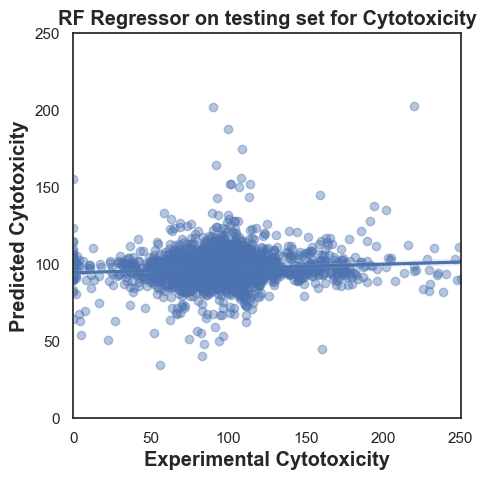

In [15]:
import seaborn as sns
import matplotlib.pyplot as plt

sns.set(color_codes=True)
sns.set_style("white")

ax = sns.regplot(x=Y_test, y=Y_pred_test, scatter_kws={'alpha':0.4})
ax.set_xlabel('Experimental Cytotoxicity', fontsize='large', fontweight='bold')
ax.set_ylabel('Predicted Cytotoxicity', fontsize='large', fontweight='bold')
ax.set_title('RF Regressor on testing set for Cytotoxicity', fontsize='large', fontweight='bold')
ax.set_xlim(0,250)
ax.set_ylim(0,250)
ax.figure.set_size_inches(5,5)
plt.show()

In [16]:
#See accuracy of the model
from sklearn.metrics import mean_squared_error, r2_score
print('Mean squared error (MSE) in testing set: %.2f'
      % mean_squared_error(Y_test, Y_pred_test))
print('Coefficient of determination in testing set (R^2): %.2f'
      % r2_score(Y_test, Y_pred_test))

Mean squared error (MSE) in testing set: 730.23
Coefficient of determination in testing set (R^2): -0.04


In [11]:
from sklearn.model_selection import cross_val_score, KFold
import numpy as np

# Define the cross-validation strategy (e.g., 5-fold cross-validation)
kf = KFold(n_splits=5, shuffle=True, random_state=42)

# Perform 5-fold Cross-Validation using the best hyperparameters over the ENTIRE dataset
cv_scores = cross_val_score(model, X, Y, cv=kf, scoring='r2')

print(f"Cross-validation R2 scores (on modeling set): {cv_scores}")
print(f"Mean R2 score (on modeling set): {np.mean(cv_scores):.2f}")
print(f"Standard deviation of R2 scores (on modeling set): {np.std(cv_scores):.2f}")

KeyboardInterrupt: 

In [ ]:
import numpy as np
import matplotlib.pyplot as plt
from sklearn.ensemble import RandomForestRegressor
from sklearn.model_selection import cross_val_score, KFold

# 1. Setup parameters
n_permutations = 50  # Number of times to shuffle the Y values
scrambled_r2_scores = []
rf_model = RandomForestRegressor(n_estimators=100, random_state=42)
kf = KFold(n_splits=5, shuffle=True, random_state=42)

# Original Mean R2 (from your previous calculation)
# Let's assume it's stored in np.mean(r2_scores_cv)
original_r2 = np.mean(cv_scores)

print(f"Starting Y-scrambling with {n_permutations} iterations...")

# 2. The Scrambling Loop
for i in range(n_permutations):
    # Shuffle only the Y_modeling labels
    Y_shuffled = np.random.permutation(Y_modeling)

    # Calculate cross-validation R2 on the fake data
    scores = cross_val_score(rf_model, X_modeling, Y_shuffled, cv=kf, scoring='r2')
    scrambled_r2_scores.append(np.mean(scores))

# 3. Visualization
plt.figure(figsize=(8, 5))
plt.hist(scrambled_r2_scores, bins=15, alpha=0.7, label='Scrambled $R^2$')
plt.axvline(original_r2, color='red', linestyle='--', label=f'Original $R^2$ ({original_r2:.2f})')
plt.title('Y-Scrambling Test Results')
plt.xlabel('$R^2$ Score')
plt.ylabel('Frequency')
plt.legend()
plt.show()

# 4. Success Metric
print(f"Average Scrambled R2: {np.mean(scrambled_r2_scores):.3f}")
if original_r2 > np.mean(scrambled_r2_scores) + 2 * np.std(scrambled_r2_scores):
    print("SUCCESS: The model is statistically robust.")
else:
    print("WARNING: The model might be based on chance correlations.")